In [11]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env")  # notebook lives in tracer/, .env is here

required = ["GROQ_API_KEY", "TAVILY_API_KEY", "ANTHROPIC_API_KEY"]
missing = [k for k in required if not os.getenv(k)]
if missing:
    print(f"WARNING: missing env vars: {missing}")
else:
    print("All keys loaded.")

All keys loaded.


## 2. State & Schemas

In [12]:
from typing import TypedDict
from pydantic import BaseModel


class ResearchState(TypedDict):
    question: str
    search_plan: list[str]
    search_results: list[dict]
    sources_read: list[dict]
    synthesis: str
    citations: list[dict]
    failures: list[dict]


class Citation(BaseModel):
    id: int
    url: str
    title: str
    snippet: str
    relevance_score: float = 0.0


class Section(BaseModel):
    heading: str
    content: str
    citation_ids: list[int]


class ResearchReport(BaseModel):
    title: str
    summary: str
    sections: list[Section]
    citations: list[Citation]
    confidence_note: str = ""
    data_gaps: list[str] = []


print("State and schemas defined.")

State and schemas defined.


## 3. Tools (Tavily search + page fetcher)

In [13]:
import time
from datetime import datetime, timezone

import requests
from bs4 import BeautifulSoup
from tavily import TavilyClient

_tavily_client = None


def tavily_search(query: str, max_results: int = 5) -> list[dict]:
    global _tavily_client
    if _tavily_client is None:
        _tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = _tavily_client.search(query=query, max_results=max_results)
    return [
        {
            "query": query,
            "url": r.get("url", ""),
            "title": r.get("title", ""),
            "snippet": r.get("content", ""),
            "score": r.get("score", 0.0),
        }
        for r in response.get("results", [])
    ]


_STRIP_TAGS = ["nav", "footer", "header", "script", "style", "aside", "noscript"]


def fetch_page(url: str) -> tuple[dict | None, dict | None]:
    ts = datetime.now(timezone.utc).isoformat()

    def _fail(ftype, msg):
        return {"node": "read_sources", "type": ftype, "url": url,
                "message": msg, "recovery_action": "skipped", "timestamp": ts}

    try:
        resp = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    except requests.exceptions.Timeout:
        return None, _fail("timeout", "No response after 10s")
    except requests.exceptions.RequestException as e:
        return None, _fail("request_error", str(e))

    if "text/html" not in resp.headers.get("Content-Type", ""):
        return None, _fail("non_html", resp.headers.get("Content-Type", ""))
    if resp.status_code == 403:
        return None, _fail("http_403", "403 Forbidden")
    if resp.status_code == 404:
        return None, _fail("http_404", "404 Not Found")
    if not resp.ok:
        return None, _fail(f"http_{resp.status_code}", f"HTTP {resp.status_code}")

    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(_STRIP_TAGS):
        tag.decompose()
    text = " ".join(soup.get_text(separator=" ").split())
    title = soup.title.string.strip() if soup.title and soup.title.string else ""

    if len(text) < 200:
        return None, _fail("js_rendered", f"Only {len(text)} chars after strip")
    if len(text) < 500:
        return None, _fail("paywall_suspected", f"Only {len(text)} chars")

    return {"url": url, "title": title, "content": text[:8000], "fetched_at": ts}, None


print("Tools defined.")

Tools defined.


## 4. Nodes & Tracer

In [14]:
import sys
import json
from datetime import datetime, timezone

from langchain_groq import ChatGroq

sys.path.insert(0, "..")
from sdk.tracer_callback import CustomTracer

tracer = CustomTracer(
    endpoint=os.getenv("TRACER_ENDPOINT", "http://localhost:8000"),
    project="dem",
    api_key=os.getenv("TRACER_API_KEY", "change-me"),
)


def _llm():
    return ChatGroq(
        model="llama-3.3-70b-versatile",
        api_key=os.environ["GROQ_API_KEY"],
    ).with_config({"callbacks": [tracer]})


# ── plan_searches ──────────────────────────────────────────────────────────────
def plan_searches(state: ResearchState) -> dict:
    prompt = (
        f"You are a research planner. Given the question below, generate 3-5 targeted search queries.\n"
        f"Return ONLY a JSON array of strings, no explanation.\n\n"
        f"Question: {state['question']}"
    )
    raw = _llm().invoke(prompt).content.strip()
    try:
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        queries = json.loads(raw)
        if not isinstance(queries, list):
            raise ValueError
    except Exception:
        queries = [state["question"]]
    print(f"  [plan_searches] queries={queries}")
    return {"search_plan": queries}


# ── execute_searches ───────────────────────────────────────────────────────────
def execute_searches(state: ResearchState) -> dict:
    failures = list(state.get("failures") or [])
    results = []
    for query in state.get("search_plan") or []:
        try:
            results.extend(tavily_search(query, max_results=5))
        except Exception as e:
            failures.append({"node": "execute_searches", "message": str(e),
                              "timestamp": datetime.now(timezone.utc).isoformat()})
    print(f"  [execute_searches] +{len(results)} results")
    return {"search_results": results, "failures": failures}


# ── read_sources ───────────────────────────────────────────────────────────────
def read_sources(state: ResearchState) -> dict:
    failures = list(state.get("failures") or [])
    sources_read = []
    candidates = sorted(state.get("search_results") or [], key=lambda r: r.get("score", 0.0), reverse=True)
    for result in candidates:
        if len(sources_read) >= 3:
            break
        page, failure = fetch_page(result.get("url", ""))
        if failure:
            failures.append(failure)
        else:
            sources_read.append(page)
    print(f"  [read_sources] fetched={len(sources_read)}")
    return {"sources_read": sources_read, "failures": failures}


# ── synthesize ─────────────────────────────────────────────────────────────────
def synthesize(state: ResearchState) -> dict:
    sources_read = state.get("sources_read") or []
    if not sources_read:
        report = ResearchReport(
            title="Research could not be completed",
            summary="No sources were successfully retrieved.",
            sections=[], citations=[], data_gaps=[],
        )
        return {"synthesis": report.model_dump_json(), "citations": []}

    sources_text = "\n---\n".join(
        f"[{i+1}] Title: {s['title']}\nURL: {s['url']}\nContent:\n{s['content']}"
        for i, s in enumerate(sources_read)
    )
    prompt = (
        f"You are a research analyst. Write a structured research report answering the question below.\n"
        f"Use only information from the provided sources. Include inline citation IDs.\n\n"
        f"Question: {state['question']}\n\nSources:\n{sources_text}"
    )
    try:
        report: ResearchReport = _llm().with_structured_output(ResearchReport).invoke(prompt)
    except Exception:
        raw = _llm().invoke(prompt).content.strip()
        try:
            report = ResearchReport(**json.loads(raw))
        except Exception:
            report = ResearchReport(title=state["question"], summary=raw[:500], sections=[], citations=[])
    citations = [c.model_dump() for c in report.citations]
    print(f"  [synthesize] title='{report.title}' sections={len(report.sections)}")
    return {"synthesis": report.model_dump_json(), "citations": citations}


print("Nodes and tracer defined.")

Nodes and tracer defined.


## 5. Build Graph

In [15]:
from langgraph.graph import StateGraph, END

builder = StateGraph(ResearchState)

builder.add_node("plan_searches", plan_searches)
builder.add_node("execute_searches", execute_searches)
builder.add_node("read_sources", read_sources)
builder.add_node("synthesize", synthesize)

builder.set_entry_point("plan_searches")
builder.add_edge("plan_searches", "execute_searches")
builder.add_edge("execute_searches", "read_sources")
builder.add_edge("read_sources", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


## 6. Visualize Graph

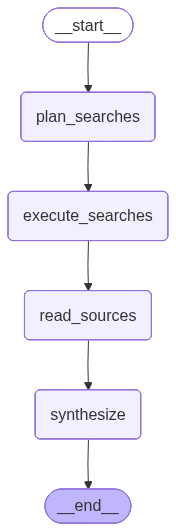

In [16]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 7. Invoke with one question

In [19]:
initial_state: ResearchState = {
    "question": "What is LangChain",
    "search_plan": [],
    "search_results": [],
    "sources_read": [],
    "synthesis": "",
    "citations": [],
    "failures": [],
}

print(f"Running: '{initial_state['question']}'\n")
result = graph.invoke(initial_state)

print("\n── Summary ──")
print(f"sources read: {len(result.get('sources_read', []))}")
print(f"failures    : {len(result.get('failures', []))}")
print(f"citations   : {len(result.get('citations', []))}")
print(f"traces sent to: {tracer._endpoint} (project={tracer._project})")

Running: 'What is LangChain'

  [plan_searches] queries=['LangChain definition', 'What is LangChain AI', 'LangChain explanation', 'LangChain use cases', 'LangChain overview']
  [execute_searches] +25 results
  [read_sources] fetched=3
  [synthesize] title='What is LangChain?' sections=3

── Summary ──
sources read: 3
failures    : 0
citations   : 3
traces sent to: http://localhost:8000 (project=dem)


## 8. Print Report

In [20]:
import json

synthesis = result.get("synthesis", "")
try:
    report = json.loads(synthesis)
    print(f"Title   : {report['title']}")
    print(f"Summary : {report['summary']}\n")
    for s in report.get("sections", []):
        print(f"### {s['heading']}")
        print(s["content"])
        print()
    print("Citations:")
    for c in report.get("citations", []):
        score = c.get('relevance_score', 0)
        print(f"  [{c['id']}] {c['title']} ({score:.2f}) — {c['url']}")
except Exception:
    print(synthesis)

Title   : What is LangChain?
Summary : LangChain is an open-source framework for building applications based on large language models (LLMs). It provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate.

### Introduction
LangChain is an open-source framework for building applications based on large language models (LLMs) [1].

### Key Features
LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate [2].

### Benefits
LangChain offers various benefits, including open source and community benefits, modular design, simplified development, repurposed LLMs, and interactive applications [3].

Citations:
  [1] Use cases with Langchain. Why LangChain? (0.80) — https://medium.com/@ebruboyaci/use-cases-with-langchain-e0fd5b0587f1
  [2] What is LangChain? - LangChain Explained - AWS (0.90) — https://aws.amazon.com/what-is/langchain
  [3] What Is LangCh